# 03 - Regressao Logistica

## Conceito
Apesar do nome, e um modelo de classificacao. Ele estima a probabilidade
de uma amostra pertencer a uma classe usando a funcao sigmoide:

    p = 1 / (1 + exp(-(b0 + b1*x1 + ... + bn*xn)))

A saida e uma probabilidade entre 0 e 1. O limite de decisao padrao e 0.5.

## Extensoes
- Multinomial: para mais de duas classes (softmax)
- OvR (one-vs-rest): treina um classificador binario por classe

## Metricas
- Acuracia, precision, recall, F1
- Matriz de confusao
- ROC-AUC

## Quando usar
- Classificacao binaria ou multiclasse
- Precisa de probabilidades, nao apenas rotulo
- Relacao aproximadamente linear entre features e log-odds

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)

# Dataset cancer de mama: binario (maligno/benigno)
dados = load_breast_cancer()
X, y = dados.data, dados.target # type: ignore

print("X:", X.shape)
print("Classes:", dados.target_names) # type: ignore
print("Contagem:", np.bincount(y))

X: (569, 30)
Classes: ['malignant' 'benign']
Contagem: [212 357]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

print("Acuracia:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 3))

Acuracia: 0.965
ROC-AUC : 0.996


c:\Users\ivanI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline: escala os dados e depois treina o modelo
modelo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

print("Acuracia:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 3))

Acuracia: 0.982
ROC-AUC : 0.995


In [11]:
# Matriz de confusao
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusao:")
print(cm)

print("\nRelatorio de classificacao:")
print(classification_report(y_test, y_pred, target_names=dados.target_names)) # type: ignore

Matriz de confusao:
[[41  1]
 [ 1 71]]

Relatorio de classificacao:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Curva ROC

A curva ROC plota taxa de verdadeiros positivos contra taxa de falsos
positivos em varios limiares. A area sob a curva (AUC) resume o desempenho:
0.5 e aleatorio, 1.0 e perfeito.

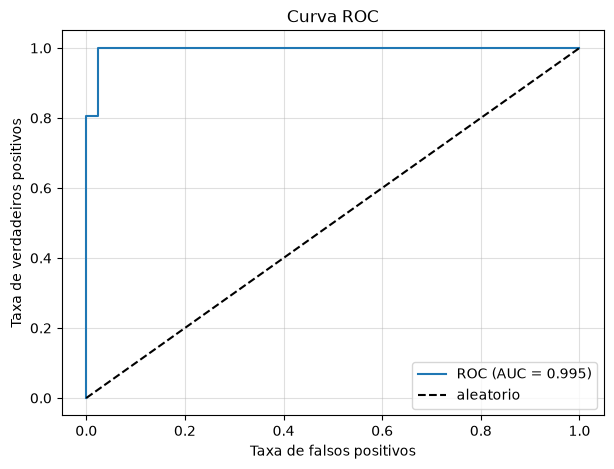

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, limiares = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="aleatorio")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## Escolhendo o limiar

O limiar padrao de 0.5 raramente e o melhor. Dependendo do problema,
podemos priorizar recall (detectar todos os positivos) ou precision.

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

for limiar in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_lim = (y_prob >= limiar).astype(int)
    p = precision_score(y_test, y_pred_lim)
    r = recall_score(y_test, y_pred_lim)
    f = f1_score(y_test, y_pred_lim)
    print(f"limiar={limiar:.1f} precision={p:.3f} recall={r:.3f} f1={f:.3f}")

limiar=0.3 precision=0.973 recall=1.000 f1=0.986
limiar=0.4 precision=0.986 recall=0.986 f1=0.986
limiar=0.5 precision=0.986 recall=0.986 f1=0.986
limiar=0.6 precision=0.986 recall=0.944 f1=0.965
limiar=0.7 precision=0.985 recall=0.931 f1=0.957


## Importancia das features

Em regressao logistica, os coeficientes indicam a direcao e a magnitude
do efeito de cada feature no log-odds da classe positiva.

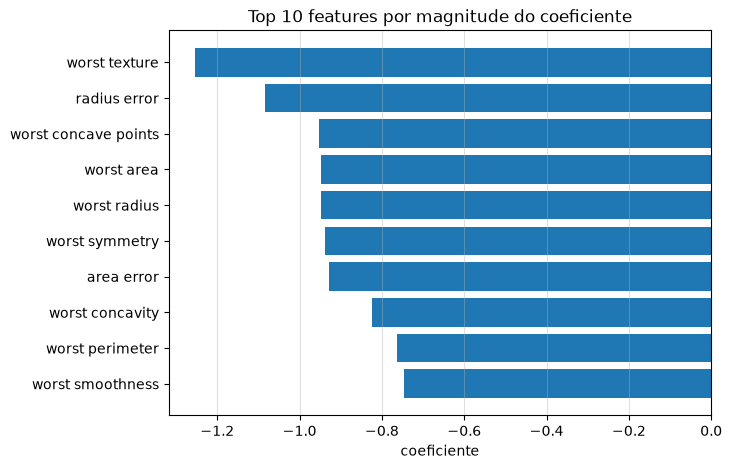

In [14]:
coeficientes = modelo.named_steps["logisticregression"].coef_[0]
ordem = np.argsort(np.abs(coeficientes))[::-1][:10]

plt.figure(figsize=(7, 5))
plt.barh(
    [dados.feature_names[i] for i in ordem][::-1], # type: ignore
    [coeficientes[i] for i in ordem][::-1],
    color="tab:blue",
)
plt.xlabel("coeficiente")
plt.title("Top 10 features por magnitude do coeficiente")
plt.grid(axis="x", alpha=0.4)
plt.show()

## Exercicios

1. Treine no dataset iris (multiclasse) e veja o classification_report.
2. Compare LogisticRegression com e sem regularizacao (penalty="l2" vs "none").
3. Encontre o limiar que maximiza F1 no conjunto de teste.
4. Explique quando recall e mais importante que precision em um problema real.